# Use MDS to get a similarity index

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [8]:
# Load survey data

def parse_year(year_val):
    """Convert year string like '2022S', '2022A', '2022W' to numeric year."""
    if isinstance(year_val, str):
        if year_val.endswith("S"):
            return int(year_val[:-1]) - 0.5
        elif year_val.endswith(("A", "W")):
            return int(year_val[:-1])
        else:
            return int(year_val)  # just in case it's string but plain year
    return int(year_val)  # if it's already an int
    


# Set up paths
folder_path = "EU_dataset"
file_title = "Cleaned_Parlemeter_Data-LeftRight"
file_name = file_title + ".xlsx"
survey_file = os.path.join(folder_path, file_name)

sheets = pd.ExcelFile(survey_file).sheet_names[1:]  # Skip 'RowHeaders'

survey_data = []

for sheet in sheets:
    country = sheet.split("-")[0]  # Extract country code (e.g., "BE")
    df_sheet = pd.read_excel(survey_file, sheet_name=sheet, header=None)
    
    # Years are in the first row
    years = df_sheet.iloc[0, :].tolist()
    
    # Extract counts for positions 1-10 (skip % rows and DK/Refusal)
    counts_matrix = []
    for i in range(10):  # Positions 1-10
        row_index = 2 + 2 * i  # Count rows are at indices 1,3,5,...,19
        counts_matrix.append(df_sheet.iloc[row_index, :].tolist())
    # print(counts_matrix)
    # Process each year
    for j, year in enumerate(years):
        year_num = parse_year(year)  # use parsed numeric year
        counts = [float(counts_matrix[i][j]) for i in range(10)]
        total_valid = sum(counts)
        distribution = [c / total_valid for c in counts]
        pooled_counts = counts[:4] + [counts[4] + counts[5]] + counts[6:]
        pooled_distribution = [c / total_valid for c in pooled_counts]
    
        survey_data.append({
            "country": country,
            "year": year_num,
            "binned_distribution": distribution,
            "binned_distribution_5_6clubbed": pooled_distribution,
            "total_respondents": total_valid
        })
survey_df = pd.DataFrame(survey_data)

In [17]:
survey_df

,country,year,binned_distribution,binned_distribution_5_6clubbed,total_respondents
0,BE,2007,"[0.03948772678762007, 0.030949839914621132, 0....","[0.03948772678762007, 0.030949839914621132, 0....",937.0
1,BE,2010,"[0.04880694143167028, 0.04121475054229935, 0.0...","[0.04880694143167028, 0.04121475054229935, 0.0...",922.0
2,BE,2012,"[0.03479125248508946, 0.040755467196819085, 0....","[0.03479125248508946, 0.040755467196819085, 0....",1006.0
3,BE,2014,"[0.06989247311827956, 0.02795698924731183, 0.1...","[0.06989247311827956, 0.02795698924731183, 0.1...",930.0
4,BE,2015,"[0.035343035343035345, 0.033264033264033266, 0...","[0.035343035343035345, 0.033264033264033266, 0...",962.0
...,...,...,...,...,...
460,HR,2022,"[0.057385759829968117, 0.026567481402763018, 0...","[0.057385759829968117, 0.026567481402763018, 0...",941.0
461,HR,2023,"[0.06465067778936393, 0.026068821689259645, 0....","[0.06465067778936393, 0.026068821689259645, 0....",959.0
462,HR,2024,"[0.05834186284544524, 0.02354145342886387, 0.0...","[0.05834186284544524, 0.02354145342886387, 0.0...",977.0
463,HR,2024,"[0.06951871657754011, 0.017112299465240642, 0....","[0.06951871657754011, 0.017112299465240642, 0....",935.0


## Creating Countrywise pooled distributions for MDS

In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import normalize

# Assuming your df has these columns
def pool_country_distributions(df):
    """
    Pool distributions per country weighted by total_respondents
    """
    pooled = []
    
    for country in df['country'].unique():
        country_data = df[df['country'] == country]
        
        # Extract the 9-bin distributions as a matrix
        dist_matrix = np.array(country_data['binned_distribution_5_6clubbed'].tolist())
        
        # Weight by total respondents
        weights = country_data['total_respondents'].values.reshape(-1, 1)
        
        # Weighted average
        weighted_dist = np.average(dist_matrix, axis=0, weights=weights.flatten())
        
        # Renormalize (should already sum to 1, but safe)
        weighted_dist = weighted_dist / weighted_dist.sum()
        
        pooled.append({
            'country': country,
            'pooled_distribution': weighted_dist
        })
    
    return pd.DataFrame(pooled)

## MDS

Distance matrix shape: (28, 28)
Distance range: [0.0000, 0.2730]
Is it symmetric? True


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


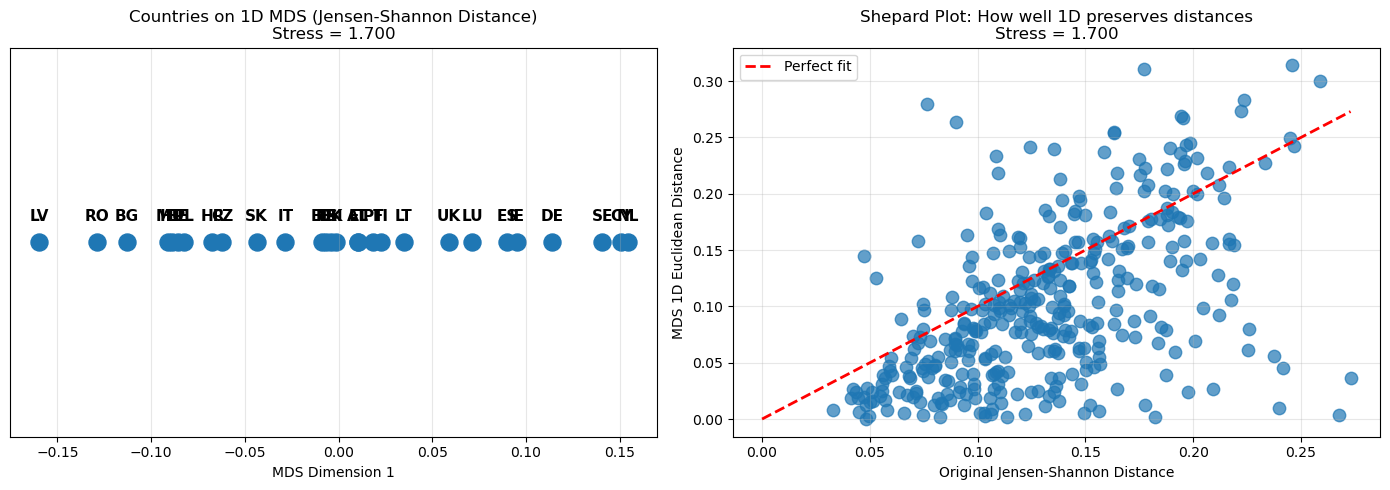


MDS Stress (lower is better): 1.700
Interpretation: Poor fit
Ordered countries (from low to high on dimension):
   1. LV: -0.1596
   2. RO: -0.1287
   3. BG: -0.1130
   4. MT: -0.0907
   5. HU: -0.0888
   6. EE: -0.0859
   7. PL: -0.0823
   8. HR: -0.0673
   9. CZ: -0.0621
  10. SK: -0.0437
  11. IT: -0.0285
  12. BE: -0.0088
  13. FR: -0.0066
  14. DK: -0.0039
  15. SI: -0.0017
  16. AT: 0.0102
  17. EL: 0.0105
  18. PT: 0.0184
  19. FI: 0.0227
  20. LT: 0.0349
  21. UK: 0.0588
  22. LU: 0.0712
  23. ES: 0.0899
  24. IE: 0.0951
  25. DE: 0.1140
  26. SE: 0.1406
  27. CY: 0.1508
  28. NL: 0.1543


In [21]:
import pandas as pd
import numpy as np
from sklearn.manifold import MDS
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform, jensenshannon
from scipy.stats import gmean
import matplotlib.pyplot as plt

def pool_country_distributions(df):
    """Pool distributions per country weighted by total_respondents"""
    pooled = []
    
    for country in df['country'].unique():
        country_data = df[df['country'] == country]
        dist_matrix = np.array(country_data['binned_distribution_5_6clubbed'].tolist())
        weights = country_data['total_respondents'].values.reshape(-1, 1)
        
        # Weighted average
        weighted_dist = np.average(dist_matrix, axis=0, weights=weights.flatten())
        weighted_dist = weighted_dist / weighted_dist.sum()  # Renormalize
        
        pooled.append({
            'country': country,
            'pooled_distribution': weighted_dist
        })
    
    return pd.DataFrame(pooled)

def analyze_with_js_distance(survey_df):
    """
    Analyze country distributions using Jensen-Shannon DISTANCE (metric)
    """
    # Step 1: Pool per country
    pooled_df = pool_country_distributions(survey_df)
    distributions = np.array(pooled_df['pooled_distribution'].tolist())
    
    # Step 2: Compute pairwise Jensen-Shannon DISTANCES
    # scipy's jensenshannon returns sqrt(JSD) = TRUE DISTANCE
    # It's a proper metric!
    js_distance_matrix = squareform(pdist(distributions, metric=jensenshannon))
    
    print(f"Distance matrix shape: {js_distance_matrix.shape}")
    print(f"Distance range: [{js_distance_matrix.min():.4f}, {js_distance_matrix.max():.4f}]")
    print(f"Is it symmetric? {np.allclose(js_distance_matrix, js_distance_matrix.T)}")
    
    # Step 3: MDS to 1D using the distance matrix
    mds = MDS(
        n_components=1,
        dissimilarity='precomputed',
        random_state=42,
        normalized_stress='auto'
    )
    country_coords_1d = mds.fit_transform(js_distance_matrix)
    
    # Step 4: Add to dataframe and order
    pooled_df['mds_1d'] = country_coords_1d.flatten()
    ordered_countries = pooled_df.sort_values('mds_1d')['country'].tolist()
    
    # Step 5: Quality check - Shepard plot
    orig_dists = pdist(distributions, metric=jensenshannon)
    mds_dists = pdist(country_coords_1d.reshape(-1, 1), metric='euclidean')
    
    # Step 6: Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1D projection
    axes[0].scatter(pooled_df['mds_1d'], np.zeros_like(pooled_df['mds_1d']), s=150)
    for i, row in pooled_df.iterrows():
        axes[0].annotate(row['country'], (row['mds_1d'], 0), 
                        xytext=(0, 15), textcoords='offset points',
                        ha='center', fontsize=11, fontweight='bold')
    axes[0].set_title(f'Countries on 1D MDS (Jensen-Shannon Distance)\nStress = {mds.stress_:.3f}')
    axes[0].set_xlabel('MDS Dimension 1')
    axes[0].set_yticks([])
    axes[0].grid(alpha=0.3)
    
    # Shepard plot
    axes[1].scatter(orig_dists, mds_dists, alpha=0.7, s=80)
    axes[1].plot([0, orig_dists.max()], [0, orig_dists.max()], 'r--', 
                linewidth=2, label='Perfect fit')
    axes[1].set_xlabel('Original Jensen-Shannon Distance')
    axes[1].set_ylabel('MDS 1D Euclidean Distance')
    axes[1].set_title(f'Shepard Plot: How well 1D preserves distances\n'
                     f'Stress = {mds.stress_:.3f}')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Report
    print("\n" + "="*60)
    print(f"MDS Stress (lower is better): {mds.stress_:.3f}")
    print(f"Interpretation: {'Excellent fit' if mds.stress_ < 0.1 else 'Good fit' if mds.stress_ < 0.2 else 'Mediocre fit' if mds.stress_ < 0.3 else 'Poor fit'}")
    print(f"Ordered countries (from low to high on dimension):")
    for i, country in enumerate(ordered_countries, 1):
        coord = pooled_df[pooled_df['country'] == country]['mds_1d'].values[0]
        print(f"  {i:2d}. {country}: {coord:.4f}")
    print("="*60)
    
    return pooled_df, ordered_countries, mds

# Run the analysis
pooled_df, ordered, mds = analyze_with_js_distance(survey_df)

In [24]:
mds_nonmetric = MDS(n_components=1,
                    dissimilarity='precomputed',
                    metric=False,  # Non-metric MDS
                    random_state=42,
                    n_init=10)
coords_1d_nm = mds_nonmetric.fit_transform(js_distance_matrix)
print(f"Non-metric MDS Stress: {mds_nonmetric.stress_:.3f}")

NameError: name 'js_distance_matrix' is not defined

In [22]:
ordered

['LV',
 'RO',
 'BG',
 'MT',
 'HU',
 'EE',
 'PL',
 'HR',
 'CZ',
 'SK',
 'IT',
 'BE',
 'FR',
 'DK',
 'SI',
 'AT',
 'EL',
 'PT',
 'FI',
 'LT',
 'UK',
 'LU',
 'ES',
 'IE',
 'DE',
 'SE',
 'CY',
 'NL']


COUNTRY DISTRIBUTION ANALYSIS
Metric vs Non-metric MDS + Clustering

STEP 1: Pooling distributions per country...
   Pooled 28 countries
DATA QUALITY DIAGNOSTICS

1. DISTRIBUTION PROPERTIES:
   Number of countries: 28
   Number of bins: 9
   All sum to 1? True
   Min bin value: 0.008430
   Max bin value: 0.586908

2. VARIANCE STRUCTURE:
   Total variance across countries: 0.009389
   Variance per bin: [0.00049573 0.00016106 0.00097778 0.00080647 0.00474284 0.00072378
 0.0005564  0.00011986 0.00080464]
   Top 3 most variable bins: [4 2 3]

3. PAIRWISE DISTANCES (Jensen-Shannon):
   Min distance: 0.0328
   Max distance: 0.2730
   Mean distance: 0.1314
   Std distance: 0.0480

4. DISTANCE MATRIX PROPERTIES:
   Is symmetric? True
   Diagonal all zero? True


MDS COMPARISON: Metric vs Non-metric

METRIC MDS:
  1D: stress=1.236 (UNACCEPTABLE)
  2D: stress=0.172 (FAIR)
  3D: stress=0.012 (EXCELLENT)

NON-METRIC MDS:
  1D: stress=0.351 (UNACCEPTABLE)
  2D: stress=0.126 (FAIR)
  3D: stress=0.0

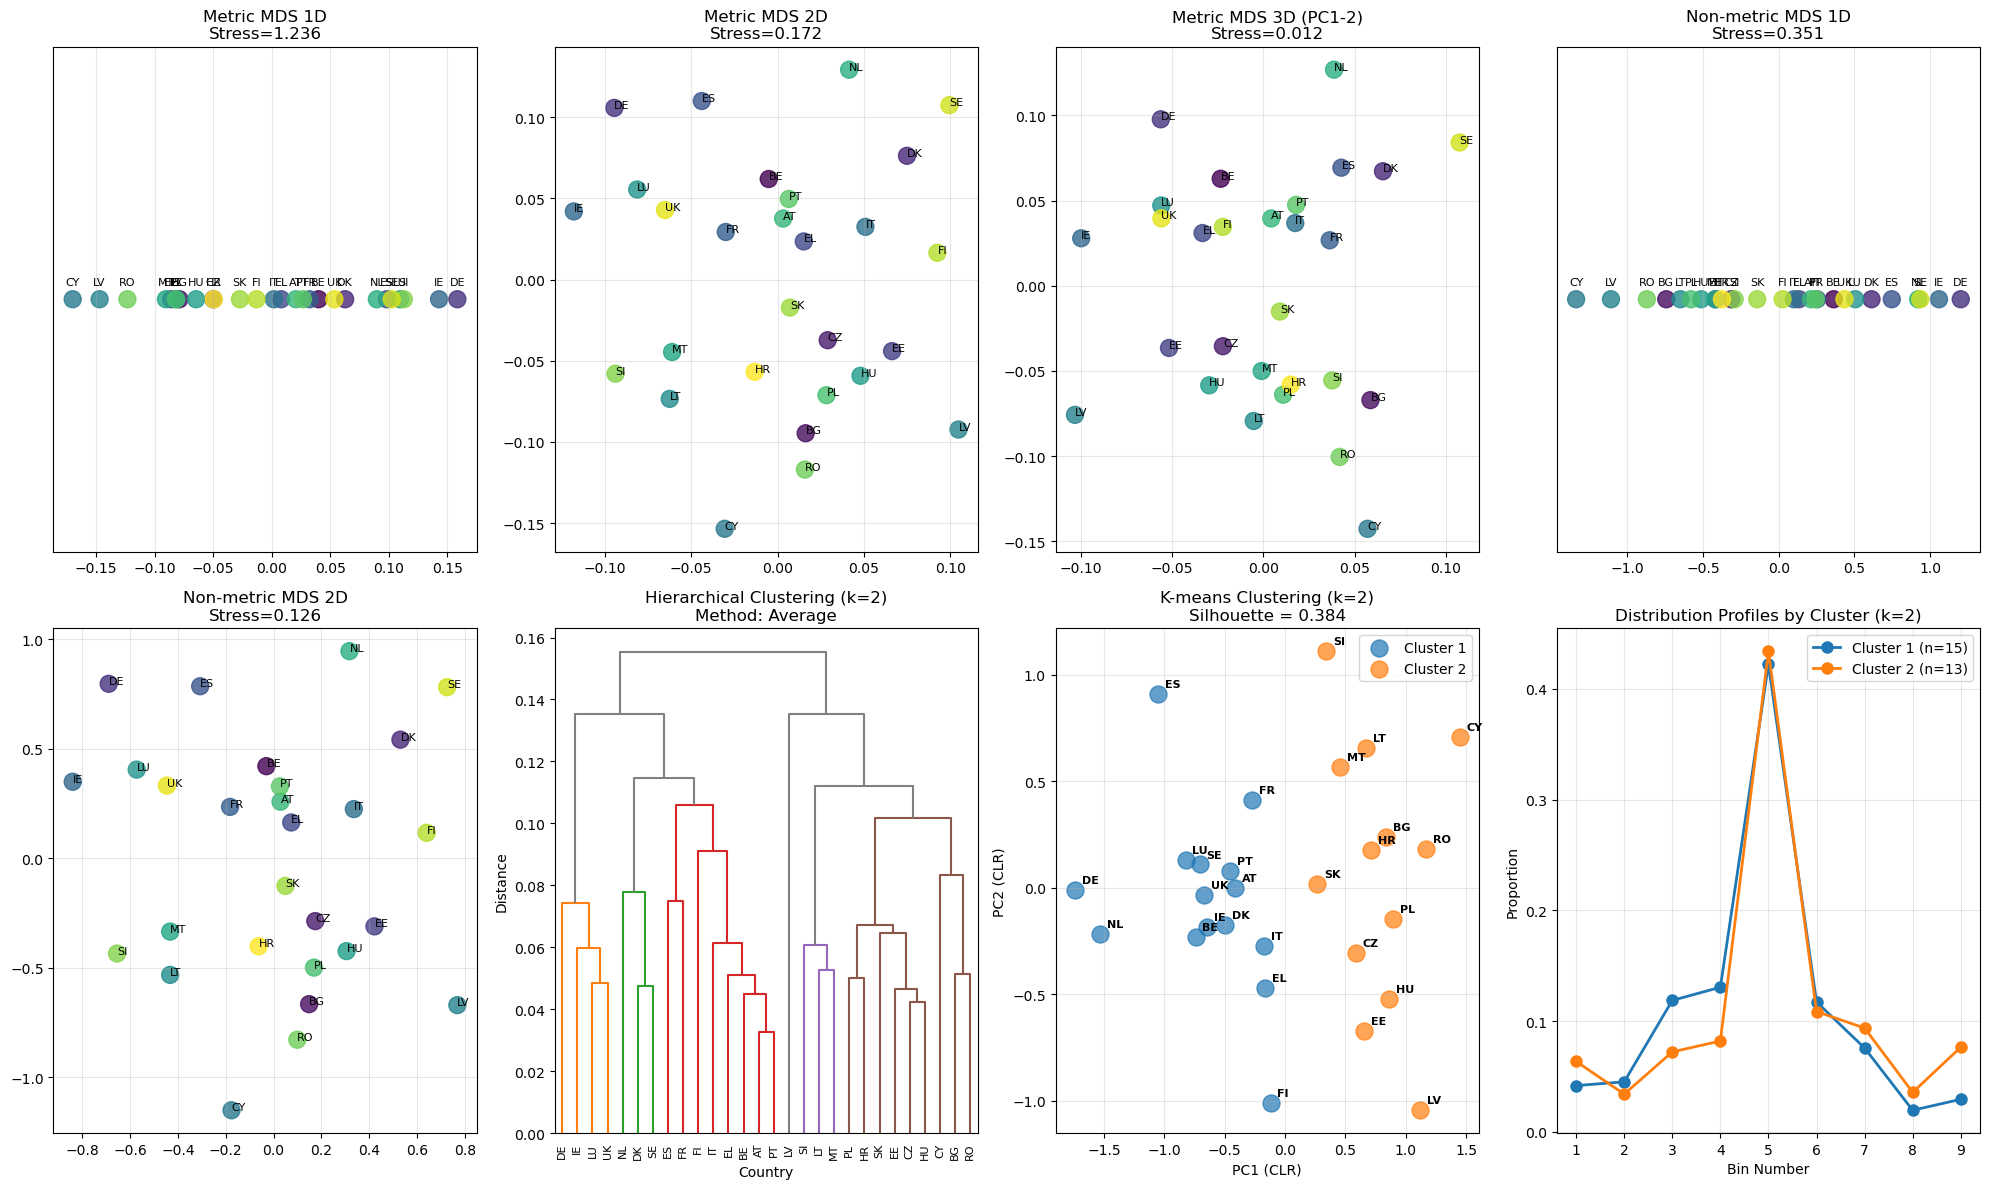


FINAL RESULTS SUMMARY

1. BEST MDS SOLUTION: METRIC with 3D
   Stress = 0.012

2. COUNTRY ORDER (by Dimension 1):
    1. LV: -0.1034
    2. IE: -0.0999
    3. DE: -0.0563
    4. LU: -0.0560
    5. UK: -0.0560
    6. EE: -0.0518
    7. EL: -0.0334
    8. HU: -0.0297
    9. BE: -0.0234
   10. FI: -0.0222
   11. CZ: -0.0222
   12. LT: -0.0053
   13. MT: -0.0010
   14. AT: 0.0043
   15. SK: 0.0090
   16. PL: 0.0108
   17. HR: 0.0150
   18. IT: 0.0175
   19. PT: 0.0179
   20. FR: 0.0363
   21. SI: 0.0377
   22. NL: 0.0387
   23. RO: 0.0418
   24. ES: 0.0427
   25. CY: 0.0571
   26. BG: 0.0587
   27. DK: 0.0655
   28. SE: 0.1076

3. HIERARCHICAL CLUSTERING (k=2):
   Cluster 1: BE, DK, DE, EL, ES, FR, IE, IT, LU, NL, AT, PT, FI, SE, UK
   Cluster 2: BG, CZ, EE, CY, LV, LT, HU, MT, PL, RO, SI, SK, HR

4. K-MEANS CLUSTERING (k=2):
   Cluster 1: BE, DK, DE, EL, ES, FR, IE, IT, LU, NL, AT, PT, FI, SE, UK
   Cluster 2: BG, CZ, EE, CY, LV, LT, HU, MT, PL, RO, SI, SK, HR

5. EXPORTING RESULTS:
   ✓

In [27]:
import pandas as pd
import numpy as np
from sklearn.manifold import MDS
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist, squareform, jensenshannon
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.stats import gmean
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# STEP 1: DATA POOLING FUNCTION
# ============================================================================

def pool_country_distributions(df):
    """
    Pool distributions per country weighted by total_respondents
    """
    pooled = []
    
    for country in df['country'].unique():
        country_data = df[df['country'] == country]
        
        # Extract distributions as matrix
        dist_matrix = np.array(country_data['binned_distribution_5_6clubbed'].tolist())
        
        # Weight by total respondents
        weights = country_data['total_respondents'].values.reshape(-1, 1)
        
        # Weighted average
        weighted_dist = np.average(dist_matrix, axis=0, weights=weights.flatten())
        
        # Renormalize (safety check)
        weighted_dist = weighted_dist / weighted_dist.sum()
        
        pooled.append({
            'country': country,
            'pooled_distribution': weighted_dist
        })
    
    return pd.DataFrame(pooled)


# ============================================================================
# STEP 2: DIAGNOSTIC FUNCTIONS
# ============================================================================

def diagnose_data_quality(pooled_df):
    """
    Comprehensive diagnostic checks before analysis
    """
    distributions = np.array(pooled_df['pooled_distribution'].tolist())
    n_countries, n_bins = distributions.shape
    
    print("="*70)
    print("DATA QUALITY DIAGNOSTICS")
    print("="*70)
    
    # 1. Distribution checks
    print("\n1. DISTRIBUTION PROPERTIES:")
    sums = distributions.sum(axis=1)
    print(f"   Number of countries: {n_countries}")
    print(f"   Number of bins: {n_bins}")
    print(f"   All sum to 1? {np.allclose(sums, 1.0)}")
    print(f"   Min bin value: {distributions.min():.6f}")
    print(f"   Max bin value: {distributions.max():.6f}")
    
    # 2. Variance across countries
    variance_per_bin = distributions.var(axis=0)
    total_variance = variance_per_bin.sum()
    print(f"\n2. VARIANCE STRUCTURE:")
    print(f"   Total variance across countries: {total_variance:.6f}")
    print(f"   Variance per bin: {variance_per_bin}")
    print(f"   Top 3 most variable bins: {np.argsort(variance_per_bin)[-3:][::-1]}")
    
    if total_variance < 0.001:
        print("   ⚠️ WARNING: Very low variance - countries are nearly identical!")
    
    # 3. Pairwise distances - keep full matrix with zeros on diagonal
    dist_matrix_full = squareform(pdist(distributions, metric=jensenshannon))
    
    # For stats, copy with nan diagonal
    dist_matrix_stats = dist_matrix_full.copy()
    np.fill_diagonal(dist_matrix_stats, np.nan)
    
    print(f"\n3. PAIRWISE DISTANCES (Jensen-Shannon):")
    print(f"   Min distance: {np.nanmin(dist_matrix_stats):.4f}")
    print(f"   Max distance: {np.nanmax(dist_matrix_stats):.4f}")
    print(f"   Mean distance: {np.nanmean(dist_matrix_stats):.4f}")
    print(f"   Std distance: {np.nanstd(dist_matrix_stats):.4f}")
    
    # 4. Near-duplicate check
    near_duplicates = np.sum(dist_matrix_stats < 0.01) / 2
    if near_duplicates > 0:
        print(f"   ⚠️ Found {int(near_duplicates)} pairs of near-identical countries (distance < 0.01)")
    
    # Check symmetry
    is_symmetric = np.allclose(dist_matrix_full, dist_matrix_full.T)
    print(f"\n4. DISTANCE MATRIX PROPERTIES:")
    print(f"   Is symmetric? {is_symmetric}")
    print(f"   Diagonal all zero? {np.allclose(np.diag(dist_matrix_full), 0)}")
    
    print("\n" + "="*70)
    
    return distributions, dist_matrix_full


# ============================================================================
# STEP 3: METRIC AND NON-METRIC MDS COMPARISON
# ============================================================================

def compare_mds_methods(pooled_df, distributions):
    """
    Compare metric vs non-metric MDS in 1D, 2D, and 3D
    """
    print("\n" + "="*70)
    print("MDS COMPARISON: Metric vs Non-metric")
    print("="*70)
    
    # Compute pairwise Jensen-Shannon distances
    dist_matrix = squareform(pdist(distributions, metric=jensenshannon))
    
    results = {
        'metric': {},
        'nonmetric': {}
    }
    
    # Test both methods for 1D, 2D, 3D
    for method_name, metric_flag in [('Metric', True), ('Non-metric', False)]:
        print(f"\n{method_name.upper()} MDS:")
        
        for n_dims in [1, 2, 3]:
            print(f"  {n_dims}D: ", end="")
            
            try:
                mds = MDS(
                    n_components=n_dims,
                    dissimilarity='precomputed',
                    metric=metric_flag,
                    random_state=42,
                    n_init=10,
                    max_iter=300,
                    eps=1e-5,
                    normalized_stress='auto'
                )
                
                coords = mds.fit_transform(dist_matrix)
                stress = mds.stress_
                
                # Interpret stress
                if stress < 0.05:
                    quality = "EXCELLENT"
                elif stress < 0.10:
                    quality = "GOOD"
                elif stress < 0.20:
                    quality = "FAIR"
                elif stress < 0.30:
                    quality = "POOR"
                else:
                    quality = "UNACCEPTABLE"
                
                print(f"stress={stress:.3f} ({quality})")
                
                if method_name.lower() == 'metric':
                    results['metric'][n_dims] = {'coordinates': coords, 'stress': stress, 'model': mds}
                else:
                    results['nonmetric'][n_dims] = {'coordinates': coords, 'stress': stress, 'model': mds}
                    
            except Exception as e:
                print(f"❌ Failed: {str(e)[:50]}")
                if method_name.lower() == 'metric':
                    results['metric'][n_dims] = None
                else:
                    results['nonmetric'][n_dims] = None
    
    # Summary recommendation
    print("\n" + "-"*70)
    print("RECOMMENDATION:")
    
    # Find best fit
    best_stress = float('inf')
    best_method = None
    best_dims = None
    
    for method in ['metric', 'nonmetric']:
        for dims in [1, 2, 3]:
            if results[method].get(dims) is not None:
                stress = results[method][dims]['stress']
                if stress < best_stress:
                    best_stress = stress
                    best_method = method
                    best_dims = dims
    
    if best_method and best_dims:
        print(f"✅ Best solution: {best_method.upper()} MDS with {best_dims}D")
        print(f"   Stress = {best_stress:.3f}")
        
        # Check if 1D is acceptable
        if results['metric'].get(1) is not None and results['metric'][1]['stress'] < 0.20:
            print(f"   ✅ 1D Metric MDS is acceptable (stress={results['metric'][1]['stress']:.3f})")
        elif results['nonmetric'].get(1) is not None and results['nonmetric'][1]['stress'] < 0.20:
            print(f"   ✅ 1D Non-metric MDS is acceptable (stress={results['nonmetric'][1]['stress']:.3f})")
        else:
            print(f"   ⚠️ 1D not recommended - use {best_dims}D instead")
    else:
        print("❌ No valid MDS solution found")
        best_method = 'nonmetric'
        best_dims = 2
    
    print("="*70)
    
    return results, best_method, best_dims


# ============================================================================
# STEP 4: CLUSTERING ANALYSIS (FIXED)
# ============================================================================

def analyze_clustering(pooled_df, distributions, dist_matrix):
    """
    Hierarchical and K-means clustering with robust error handling
    """
    print("\n" + "="*70)
    print("CLUSTERING ANALYSIS")
    print("="*70)
    
    # Ensure dist_matrix is symmetric and has zero diagonal
    if dist_matrix is None:
        dist_matrix = squareform(pdist(distributions, metric=jensenshannon))
    
    # Fix: Make sure it's symmetric
    dist_matrix = (dist_matrix + dist_matrix.T) / 2
    np.fill_diagonal(dist_matrix, 0)
    
    n_countries = len(distributions)
    n_bins = distributions.shape[1]
    
    # ========================================================================
    # 4a: Hierarchical Clustering
    # ========================================================================
    
    print("\n1. HIERARCHICAL CLUSTERING:")
    
    # Try different linkage methods
    linkage_methods = ['ward', 'complete', 'average', 'single']
    best_linkage = None
    best_cophenetic = -np.inf
    best_link_matrix = None
    
    # CLR transform for Ward's method
    gm = gmean(distributions + 1e-12, axis=1, keepdims=True)
    clr_data = np.log((distributions + 1e-12) / gm)
    
    for method in linkage_methods:
        try:
            # For ward, distance must be Euclidean
            if method == 'ward':
                link_matrix = linkage(clr_data, method='ward')
            else:
                # Use the distance matrix directly
                # Convert to condensed form
                condensed_dist = squareform(dist_matrix, checks=False)
                link_matrix = linkage(condensed_dist, method=method)
            
            # Cophenetic correlation
            coph_corr, _ = cophenet(link_matrix, squareform(dist_matrix))
            
            print(f"   {method.capitalize()}: cophenetic correlation = {coph_corr:.3f}")
            
            if coph_corr > best_cophenetic:
                best_cophenetic = coph_corr
                best_linkage = method
                best_link_matrix = link_matrix
                
        except Exception as e:
            print(f"   {method.capitalize()}: failed - {str(e)[:50]}")
    
    # If all linkage methods failed, use a fallback
    if best_linkage is None or best_link_matrix is None:
        print("\n   ⚠️ All hierarchical methods failed. Using Ward's method as fallback.")
        try:
            best_link_matrix = linkage(clr_data, method='ward')
            best_linkage = 'ward'
            best_cophenetic = 0.0
        except:
            print("   ❌ Hierarchical clustering completely failed.")
            # Create a simple linkage matrix manually
            n = len(distributions)
            best_link_matrix = np.zeros((n-1, 4))
            for i in range(n-1):
                best_link_matrix[i, 0] = i
                best_link_matrix[i, 1] = i+1
                best_link_matrix[i, 2] = 1.0
                best_link_matrix[i, 3] = i+2
            best_linkage = 'fallback'
            best_cophenetic = 0.0
    
    print(f"\n   ✓ Best linkage method: {best_linkage.capitalize()}")
    print(f"     (cophenetic correlation: {best_cophenetic:.3f})")
    
    # Determine optimal number of clusters
    max_k = min(8, n_countries - 1)
    
    if max_k < 2:
        print(f"\n   ⚠️ Only {n_countries} countries - using k=2 as default")
        optimal_k = 2
        hierarchical_clusters = np.ones(n_countries, dtype=int)
        if n_countries > 1:
            hierarchical_clusters[0] = 2
    else:
        optimal_k = 2
        best_silhouette = -1
        
        print(f"\n   Silhouette scores for different k:")
        for k in range(2, max_k + 1):
            try:
                clusters = fcluster(best_link_matrix, t=k, criterion='maxclust')
                if len(set(clusters)) > 1:
                    sil_score = silhouette_score(dist_matrix, clusters, metric='precomputed')
                    print(f"     k={k}: {sil_score:.3f}")
                    if sil_score > best_silhouette:
                        best_silhouette = sil_score
                        optimal_k = k
            except Exception as e:
                print(f"     k={k}: failed - {str(e)[:30]}")
                continue
        
        print(f"\n   ✓ Optimal k (silhouette): {optimal_k} (score: {best_silhouette:.3f})")
        
        try:
            hierarchical_clusters = fcluster(best_link_matrix, t=optimal_k, criterion='maxclust')
        except:
            hierarchical_clusters = np.ones(n_countries, dtype=int)
            if n_countries > 1:
                hierarchical_clusters[0] = 2
    
    # ========================================================================
    # 4b: K-means Clustering
    # ========================================================================
    
    print("\n2. K-MEANS CLUSTERING:")
    
    # Find optimal k for k-means
    best_k = 2
    best_sil_km = -1
    km_models = {}
    
    max_k_km = min(8, n_countries - 1)
    
    if max_k_km < 2:
        print(f"   ⚠️ Only {n_countries} countries - using k=2 as default")
        best_k = 2
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        kmeans_labels = kmeans.fit_predict(clr_data)
        km_models[2] = {'model': kmeans, 'labels': kmeans_labels, 'silhouette': 0}
    else:
        for k in range(2, max_k_km + 1):
            try:
                kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
                labels = kmeans.fit_predict(clr_data)
                if len(set(labels)) > 1:
                    sil = silhouette_score(clr_data, labels)
                    km_models[k] = {'model': kmeans, 'labels': labels, 'silhouette': sil}
                    print(f"   k={k}: silhouette = {sil:.3f}")
                    
                    if sil > best_sil_km:
                        best_sil_km = sil
                        best_k = k
            except Exception as e:
                print(f"   k={k}: failed - {str(e)[:30]}")
                continue
        
        if not km_models:
            print("   ⚠️ K-means failed. Using default k=2.")
            best_k = 2
            kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
            kmeans_labels = kmeans.fit_predict(clr_data)
            km_models[2] = {'model': kmeans, 'labels': kmeans_labels, 'silhouette': 0}
        else:
            print(f"\n   ✓ Optimal k (silhouette): {best_k} (score: {best_sil_km:.3f})")
    
    kmeans_labels = km_models[best_k]['labels'] if best_k in km_models else np.ones(n_countries, dtype=int)
    
    return {
        'hierarchical': {
            'linkage_matrix': best_link_matrix,
            'linkage_method': best_linkage,
            'clusters': hierarchical_clusters,
            'optimal_k': optimal_k,
            'cophenetic': best_cophenetic
        },
        'kmeans': {
            'labels': kmeans_labels,
            'optimal_k': best_k,
            'silhouette': best_sil_km,
            'model': km_models[best_k]['model'] if best_k in km_models else None
        },
        'clr_data': clr_data
    }


# ============================================================================
# STEP 5: VISUALIZATION FUNCTIONS
# ============================================================================

def visualize_results(pooled_df, distributions, mds_results, clustering_results, best_method, best_dims):
    """
    Comprehensive visualization of all results
    """
    
    # Create figure with multiple subplots
    fig = plt.figure(figsize=(20, 12))
    
    # ========================================================================
    # Plot 1: Metric MDS 1D, 2D, 3D comparison
    # ========================================================================
    ax1 = plt.subplot(2, 4, 1)
    if mds_results['metric'].get(1) is not None:
        coords = mds_results['metric'][1]['coordinates'].flatten()
        stress = mds_results['metric'][1]['stress']
        ax1.scatter(coords, np.zeros_like(coords), s=150, c=range(len(pooled_df)), cmap='viridis', alpha=0.8)
        for i, row in pooled_df.iterrows():
            ax1.annotate(row['country'], (coords[i], 0), xytext=(0, 10), 
                        textcoords='offset points', ha='center', fontsize=8)
        ax1.set_title(f'Metric MDS 1D\nStress={stress:.3f}')
        ax1.set_yticks([])
        ax1.grid(alpha=0.3)
    else:
        ax1.text(0.5, 0.5, 'Failed', ha='center', va='center', transform=ax1.transAxes)
        ax1.set_title('Metric MDS 1D - Failed')
    
    # ========================================================================
    # Plot 2: Metric MDS 2D
    # ========================================================================
    ax2 = plt.subplot(2, 4, 2)
    if mds_results['metric'].get(2) is not None:
        coords = mds_results['metric'][2]['coordinates']
        stress = mds_results['metric'][2]['stress']
        ax2.scatter(coords[:, 0], coords[:, 1], s=150, c=range(len(pooled_df)), cmap='viridis', alpha=0.8)
        for i, row in pooled_df.iterrows():
            ax2.annotate(row['country'], (coords[i, 0], coords[i, 1]), fontsize=8)
        ax2.set_title(f'Metric MDS 2D\nStress={stress:.3f}')
        ax2.grid(alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'Failed', ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('Metric MDS 2D - Failed')
    
    # ========================================================================
    # Plot 3: Metric MDS 3D (first 2 components)
    # ========================================================================
    ax3 = plt.subplot(2, 4, 3)
    if mds_results['metric'].get(3) is not None:
        coords = mds_results['metric'][3]['coordinates']
        stress = mds_results['metric'][3]['stress']
        ax3.scatter(coords[:, 0], coords[:, 1], s=150, c=range(len(pooled_df)), cmap='viridis', alpha=0.8)
        for i, row in pooled_df.iterrows():
            ax3.annotate(row['country'], (coords[i, 0], coords[i, 1]), fontsize=8)
        ax3.set_title(f'Metric MDS 3D (PC1-2)\nStress={stress:.3f}')
        ax3.grid(alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'Failed', ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('Metric MDS 3D - Failed')
    
    # ========================================================================
    # Plot 4: Non-metric MDS 1D, 2D, 3D comparison (best)
    # ========================================================================
    ax4 = plt.subplot(2, 4, 4)
    if mds_results['nonmetric'].get(1) is not None:
        coords = mds_results['nonmetric'][1]['coordinates'].flatten()
        stress = mds_results['nonmetric'][1]['stress']
        ax4.scatter(coords, np.zeros_like(coords), s=150, c=range(len(pooled_df)), cmap='viridis', alpha=0.8)
        for i, row in pooled_df.iterrows():
            ax4.annotate(row['country'], (coords[i], 0), xytext=(0, 10), 
                        textcoords='offset points', ha='center', fontsize=8)
        ax4.set_title(f'Non-metric MDS 1D\nStress={stress:.3f}')
        ax4.set_yticks([])
        ax4.grid(alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Failed', ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Non-metric MDS 1D - Failed')
    
    # ========================================================================
    # Plot 5: Non-metric MDS 2D (best)
    # ========================================================================
    ax5 = plt.subplot(2, 4, 5)
    if mds_results['nonmetric'].get(2) is not None:
        coords = mds_results['nonmetric'][2]['coordinates']
        stress = mds_results['nonmetric'][2]['stress']
        ax5.scatter(coords[:, 0], coords[:, 1], s=150, c=range(len(pooled_df)), cmap='viridis', alpha=0.8)
        for i, row in pooled_df.iterrows():
            ax5.annotate(row['country'], (coords[i, 0], coords[i, 1]), fontsize=8)
        ax5.set_title(f'Non-metric MDS 2D\nStress={stress:.3f}')
        ax5.grid(alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'Failed', ha='center', va='center', transform=ax5.transAxes)
        ax5.set_title('Non-metric MDS 2D - Failed')
    
    # ========================================================================
    # Plot 6: Hierarchical Dendrogram
    # ========================================================================
    ax6 = plt.subplot(2, 4, 6)
    
    link_matrix = clustering_results['hierarchical']['linkage_matrix']
    clusters_hier = clustering_results['hierarchical']['clusters']
    optimal_k = clustering_results['hierarchical']['optimal_k']
    
    if link_matrix is not None and len(link_matrix) > 0:
        dendro = dendrogram(link_matrix, 
                           labels=pooled_df['country'].tolist(),
                           ax=ax6,
                           leaf_rotation=90,
                           leaf_font_size=8,
                           color_threshold=0.7 * max(link_matrix[:, 2]) if len(link_matrix) > 0 else None,
                           above_threshold_color='gray')
        
        ax6.set_title(f'Hierarchical Clustering (k={optimal_k})\nMethod: {clustering_results["hierarchical"]["linkage_method"].capitalize()}')
        ax6.set_xlabel('Country')
        ax6.set_ylabel('Distance')
        ax6.tick_params(axis='x', rotation=90)
    else:
        ax6.text(0.5, 0.5, 'Dendrogram Unavailable', 
                ha='center', va='center', transform=ax6.transAxes, fontsize=14)
        ax6.set_title('Hierarchical Clustering - Failed')
    
    # ========================================================================
    # Plot 7: K-means Clustering
    # ========================================================================
    ax7 = plt.subplot(2, 4, 7)
    
    clr_data = clustering_results['clr_data']
    kmeans_labels = clustering_results['kmeans']['labels']
    kmeans_optimal_k = clustering_results['kmeans']['optimal_k']
    
    if clr_data is not None and len(clr_data) > 0:
        pca_vis = PCA(n_components=2)
        clr_2d = pca_vis.fit_transform(clr_data)
        
        for cluster_id in range(kmeans_optimal_k):
            mask = kmeans_labels == cluster_id
            if mask.sum() > 0:
                ax7.scatter(clr_2d[mask, 0], clr_2d[mask, 1], 
                           s=150, label=f'Cluster {cluster_id+1}',
                           alpha=0.7)
        
        for i, row in pooled_df.iterrows():
            ax7.annotate(row['country'], 
                        (clr_2d[i, 0], clr_2d[i, 1]),
                        fontsize=8, fontweight='bold',
                        xytext=(5, 5), textcoords='offset points')
        
        ax7.set_title(f'K-means Clustering (k={kmeans_optimal_k})\nSilhouette = {clustering_results["kmeans"]["silhouette"]:.3f}')
        ax7.set_xlabel('PC1 (CLR)')
        ax7.set_ylabel('PC2 (CLR)')
        ax7.legend()
        ax7.grid(alpha=0.3)
    else:
        ax7.text(0.5, 0.5, 'K-means Visualization Unavailable', 
                ha='center', va='center', transform=ax7.transAxes, fontsize=14)
        ax7.set_title('K-means Clustering - Failed')
    
    # ========================================================================
    # Plot 8: Cluster Profiles
    # ========================================================================
    ax8 = plt.subplot(2, 4, 8)
    
    hier_clusters = clustering_results['hierarchical']['clusters']
    
    if hier_clusters is not None and len(set(hier_clusters)) > 1:
        for cluster_id in range(1, clustering_results['hierarchical']['optimal_k'] + 1):
            mask = hier_clusters == cluster_id
            if mask.sum() > 0:
                cluster_mean = distributions[mask].mean(axis=0)
                ax8.plot(range(1, len(cluster_mean)+1), cluster_mean, 
                        marker='o', label=f'Cluster {cluster_id} (n={mask.sum()})',
                        linewidth=2, markersize=8)
        
        ax8.set_title(f'Distribution Profiles by Cluster (k={clustering_results["hierarchical"]["optimal_k"]})')
        ax8.set_xlabel('Bin Number')
        ax8.set_ylabel('Proportion')
        ax8.set_xticks(range(1, len(distributions[0])+1))
        ax8.legend(loc='best')
        ax8.grid(alpha=0.3)
    else:
        ax8.text(0.5, 0.5, 'Not enough clusters', 
                ha='center', va='center', transform=ax8.transAxes, fontsize=14)
        ax8.set_title('Cluster Profiles - Insufficient Data')
    
    plt.tight_layout()
    plt.show()
    
    return fig


# ============================================================================
# STEP 6: SUMMARY AND EXPORT
# ============================================================================

def summarize_results(pooled_df, mds_results, clustering_results, best_method, best_dims):
    """
    Generate comprehensive summary with country ordering and clustering
    """
    
    print("\n" + "="*70)
    print("FINAL RESULTS SUMMARY")
    print("="*70)
    
    # 1. MDS summary
    print(f"\n1. BEST MDS SOLUTION: {best_method.upper()} with {best_dims}D")
    if mds_results[best_method].get(best_dims) is not None:
        stress = mds_results[best_method][best_dims]['stress']
        print(f"   Stress = {stress:.3f}")
        
        # Get coordinates for ordering
        coords = mds_results[best_method][best_dims]['coordinates']
        
        # Sort by first dimension
        order_idx = np.argsort(coords[:, 0])
        ordered_countries = [pooled_df.iloc[i]['country'] for i in order_idx]
        
        print(f"\n2. COUNTRY ORDER (by Dimension 1):")
        for i, country in enumerate(ordered_countries, 1):
            coord = coords[pooled_df[pooled_df['country'] == country].index[0], 0]
            print(f"   {i:2d}. {country}: {coord:.4f}")
        
        # Add MDS coordinates to dataframe
        if best_dims == 1:
            pooled_df['mds_1d'] = coords.flatten()
            pooled_df['mds_2d'] = np.nan
        else:
            pooled_df['mds_1d'] = coords[:, 0]
            pooled_df['mds_2d'] = coords[:, 1]
    else:
        print("   No valid MDS solution found")
        pooled_df['mds_1d'] = np.nan
        pooled_df['mds_2d'] = np.nan
    
    # 3. Clustering summary
    hier_clusters = clustering_results['hierarchical']['clusters']
    kmeans_labels = clustering_results['kmeans']['labels']
    
    print(f"\n3. HIERARCHICAL CLUSTERING (k={clustering_results['hierarchical']['optimal_k']}):")
    if hier_clusters is not None:
        for cluster_id in range(1, clustering_results['hierarchical']['optimal_k'] + 1):
            countries = pooled_df[hier_clusters == cluster_id]['country'].tolist()
            if countries:
                print(f"   Cluster {cluster_id}: {', '.join(countries)}")
    else:
        print("   Clustering failed")
    
    print(f"\n4. K-MEANS CLUSTERING (k={clustering_results['kmeans']['optimal_k']}):")
    if kmeans_labels is not None:
        for cluster_id in range(clustering_results['kmeans']['optimal_k']):
            countries = pooled_df[kmeans_labels == cluster_id]['country'].tolist()
            if countries:
                print(f"   Cluster {cluster_id+1}: {', '.join(countries)}")
    else:
        print("   K-means failed")
    
    # 4. Export results
    print("\n5. EXPORTING RESULTS:")
    pooled_df['hierarchical_cluster'] = hier_clusters if hier_clusters is not None else np.nan
    pooled_df['kmeans_cluster'] = kmeans_labels if kmeans_labels is not None else np.nan
    
    output_df = pooled_df.copy()
    output_df['pooled_distribution'] = output_df['pooled_distribution'].apply(lambda x: ','.join([f'{v:.6f}' for v in x]))
    output_df.to_csv('country_analysis_results.csv', index=False)
    print("   ✓ Results saved to 'country_analysis_results.csv'")
    
    print("\n" + "="*70)
    
    return pooled_df


# ============================================================================
# STEP 7: MAIN EXECUTION
# ============================================================================

def main_analysis(survey_df):
    """
    Main function to run complete analysis
    """
    print("\n" + "="*70)
    print("COUNTRY DISTRIBUTION ANALYSIS")
    print("Metric vs Non-metric MDS + Clustering")
    print("="*70)
    
    # Step 1: Pool distributions per country
    print("\nSTEP 1: Pooling distributions per country...")
    pooled_df = pool_country_distributions(survey_df)
    print(f"   Pooled {len(survey_df['country'].unique())} countries")
    
    # Step 2: Diagnostics
    distributions, dist_matrix = diagnose_data_quality(pooled_df)
    
    # Step 3: Compare Metric vs Non-metric MDS
    mds_results, best_method, best_dims = compare_mds_methods(pooled_df, distributions)
    
    # Step 4: Clustering
    clustering_results = analyze_clustering(pooled_df, distributions, dist_matrix)
    
    # Step 5: Visualize
    print("\nSTEP 5: Generating visualizations...")
    fig = visualize_results(pooled_df, distributions, mds_results, clustering_results, best_method, best_dims)
    
    # Step 6: Summarize
    pooled_df_final = summarize_results(pooled_df, mds_results, clustering_results, best_method, best_dims)
    
    return {
        'pooled_df': pooled_df_final,
        'distributions': distributions,
        'dist_matrix': dist_matrix,
        'mds_results': mds_results,
        'clustering_results': clustering_results,
        'best_method': best_method,
        'best_dims': best_dims,
        'figure': fig
    }


# ============================================================================
# STEP 8: RUN THE ANALYSIS
# ============================================================================

if __name__ == "__main__":
    try:
        results = main_analysis(survey_df)
        print("\n✅ Analysis complete! Check the visualizations and CSV output.")
    except NameError:
        print("⚠️ Error: survey_df not found. Please load your dataframe first.")
        print("Example: survey_df = pd.read_csv('your_data.csv')")
    except Exception as e:
        print(f"❌ Error during analysis: {str(e)}")
        import traceback
        traceback.print_exc()

In [33]:
results['pooled_df']

,country,pooled_distribution,mds_1d,mds_2d,hierarchical_cluster,kmeans_cluster
0,BE,"[0.03802666031897168, 0.03677695786717449, 0.1...",-0.023430,0.062840,1,0
1,BG,"[0.07322480083131278, 0.04821614132317285, 0.0...",0.058688,-0.067160,2,1
2,CZ,"[0.048689364266345285, 0.02476649593250979, 0....",-0.022243,-0.035501,2,1
3,DK,"[0.047147600362209476, 0.059885300332025354, 0...",0.065534,0.067261,1,0
4,DE,"[0.029465245061575336, 0.03835027688238697, 0....",-0.056286,0.097764,1,0
5,EE,"[0.03435427379089351, 0.02749832327297116, 0.0...",-0.051783,-0.036519,2,1
6,EL,"[0.031177742970090256, 0.03080480346087865, 0....",-0.033390,0.030964,1,0
7,ES,"[0.07155709342560554, 0.05570934256055363, 0.1...",0.042739,0.069354,1,0
8,FR,"[0.0513939735285835, 0.04956350323852436, 0.14...",0.036342,0.026722,1,0
9,IE,"[0.02665106604264171, 0.027821112844513784, 0....",-0.099933,0.027891,1,0


array([1, 2], dtype=int32)

In [53]:
# hierarchical_split = .groupby('hierarchical_cluster')
hierarchical_split = {data: group for data, group in results['pooled_df'].groupby('hierarchical_cluster')}
kmeans_split = {data: group for data, group in results['pooled_df'].groupby('kmeans_cluster')}

In [54]:
hierarchical_group_1 = hierarchical_split[1]
hierarchical_group_2 = hierarchical_split[2]

kmeans_group_1 = kmeans_split[0]
kmeans_group_2 = kmeans_split[1]

In [59]:
print("Countries in H1:")
print(hierarchical_group_1['country'].unique())
print("\n \n")
print("Countries in H2:")
print(hierarchical_group_2['country'].unique())
print("\n \n")
print("Countries in K1:")
print(kmeans_group_1['country'].unique())
print("\n \n")
print("Countries in K2:")
print(kmeans_group_2['country'].unique())

Countries in H1:
['BE' 'DK' 'DE' 'EL' 'ES' 'FR' 'IE' 'IT' 'LU' 'NL' 'AT' 'PT' 'FI' 'SE'
 'UK']

 

Countries in H2:
['BG' 'CZ' 'EE' 'CY' 'LV' 'LT' 'HU' 'MT' 'PL' 'RO' 'SI' 'SK' 'HR']

 

Countries in K1:
['BE' 'DK' 'DE' 'EL' 'ES' 'FR' 'IE' 'IT' 'LU' 'NL' 'AT' 'PT' 'FI' 'SE'
 'UK']

 

Countries in K2:
['BG' 'CZ' 'EE' 'CY' 'LV' 'LT' 'HU' 'MT' 'PL' 'RO' 'SI' 'SK' 'HR']


In [69]:
cluster_order = kmeans_group_1['country'].unique().tolist().append(kmeans_group_2['country'].unique().tolist())

In [71]:
print(cluster_order)

None


In [75]:
k1 = kmeans_group_1['country'].unique()
k2 = kmeans_group_2['country'].unique()

np.concatenate((k1,k2)).tolist()

['BE',
 'DK',
 'DE',
 'EL',
 'ES',
 'FR',
 'IE',
 'IT',
 'LU',
 'NL',
 'AT',
 'PT',
 'FI',
 'SE',
 'UK',
 'BG',
 'CZ',
 'EE',
 'CY',
 'LV',
 'LT',
 'HU',
 'MT',
 'PL',
 'RO',
 'SI',
 'SK',
 'HR']